In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

# B-tree fragments

In [2]:
def load_dfs(fs):
    dfs = {}
    for fname in fs:
        freq = fname.split("_")[1]
        dfs[freq] = pd.read_csv(fname)

    return dfs

def plot_hist(dfs):
    fig, ax = plt.subplots(1,3, figsize=(20,4))

    amon = dfs["Amon"].pivot(columns="dataset", values="offset").plot.hist(stacked=True, legend=False, ax=ax[0], alpha=.5)
    day = dfs["day"].pivot(columns="dataset", values="offset").plot.hist(stacked=True, legend=False, ax=ax[1], alpha=.5)
    hr3 = dfs["3hr"].pivot(columns="dataset", values="offset").plot.hist(stacked=True, legend=False, ax=ax[2], alpha=.5)

    _ = ax[0].set_xlabel("Byte offsets of B-tree nodes (monthly).")
    _ = ax[1].set_xlabel("Byte offsets of B-tree nodes (daily).")
    _ = ax[2].set_xlabel("Byte offsets of B-tree nodes (3-hourly).")
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor=(0.5, -0.1))
    
    ax[1].set_ylabel(None)
    ax[2].set_ylabel(None)

    fig.tight_layout()

    return fig, ax

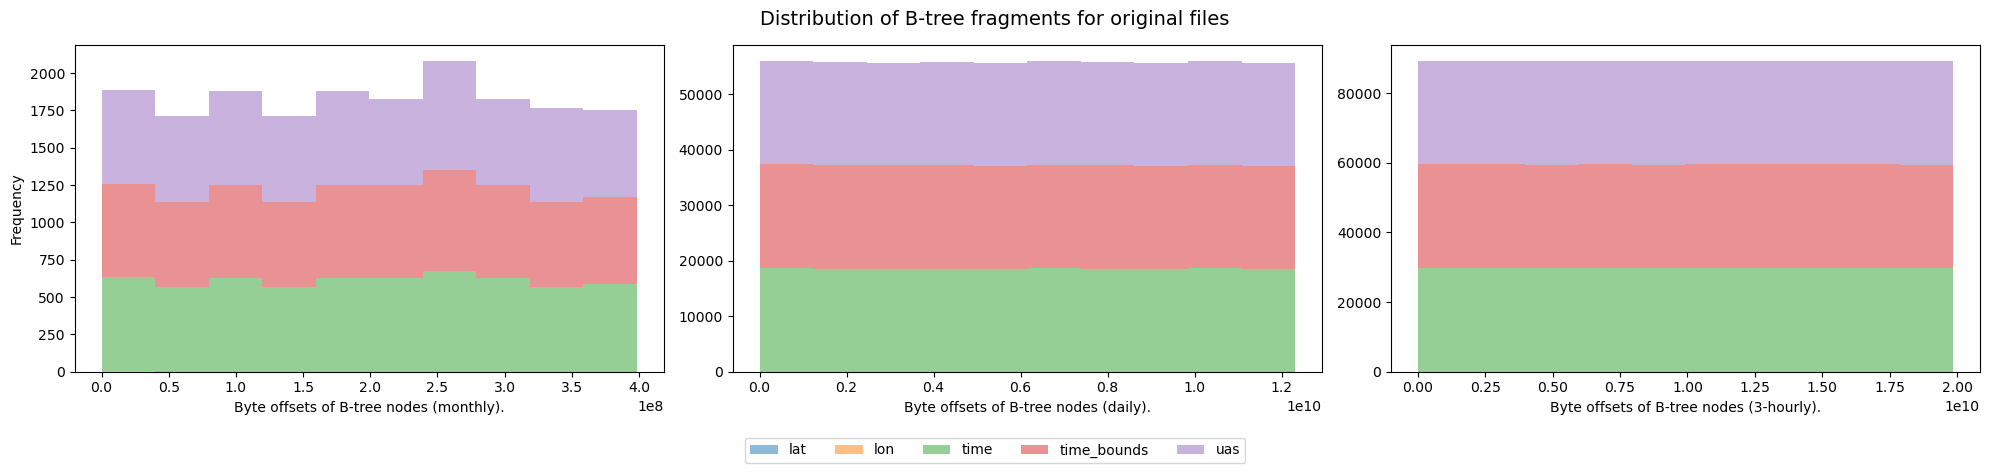

In [3]:
dfs = load_dfs([
    "csv/uas_3hr_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_187001010300-197001010000.csv.zip",
    "csv/uas_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912.csv.zip",
    "csv/uas_day_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_18500101-23491231.csv.zip",
])

fig, ax = plot_hist(dfs)
fig.suptitle("Distribution of B-tree fragments for original files", y=1.05, fontsize=14)

plt.savefig("btrees-norepack.pdf", bbox_inches="tight")

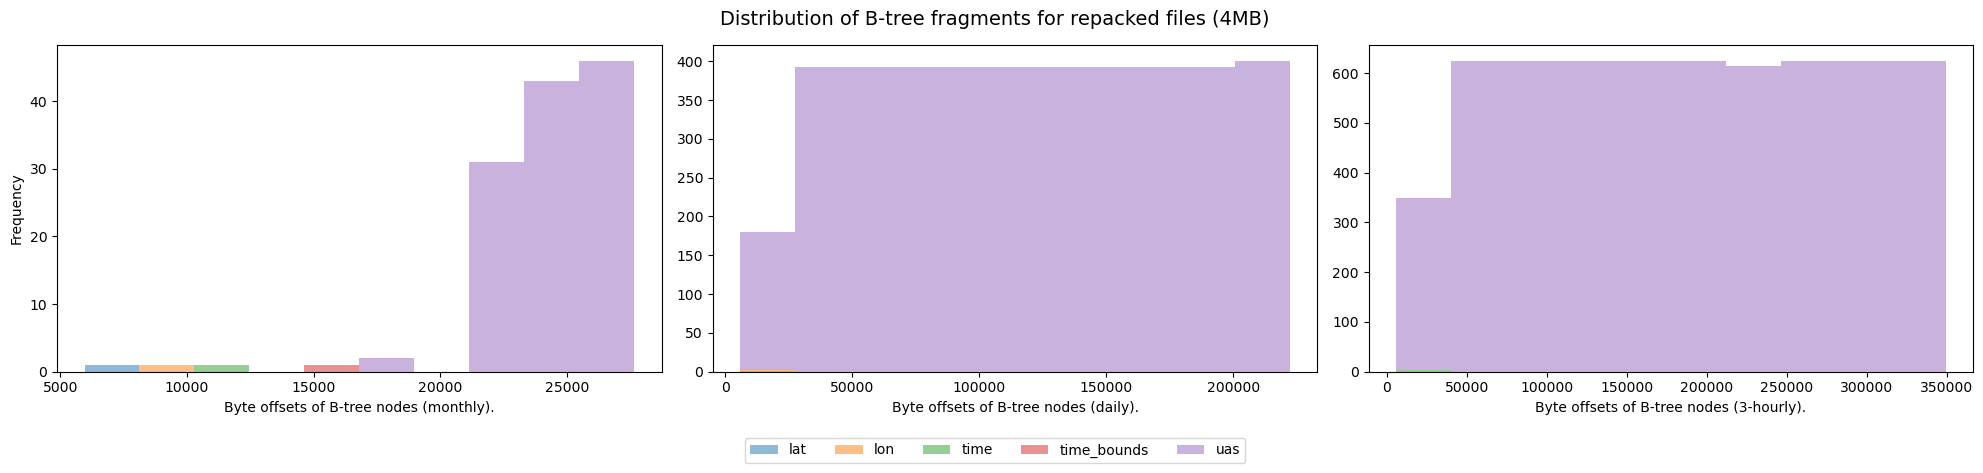

In [4]:
dfs = load_dfs([
    "csv/uas_3hr_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_187001010300-197001010000_cmip7repack4mb.csv.zip",
    "csv/uas_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912_cmip7repack4mb.csv.zip",
    "csv/uas_day_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_18500101-23491231_cmip7repack4mb.csv.zip",
])

fig, ax = plot_hist(dfs)
fig.suptitle("Distribution of B-tree fragments for repacked files (4MB)", y=1.05, fontsize=14)

plt.savefig("btrees-4mbrepack.pdf", bbox_inches="tight")

# Performance

Load the results.

In [5]:
df = pd.read_csv("results.csv")

# df = pd.read_csv("results-cr.csv")
# df["tp"] = df["bytes_recv"] / a["time"] / 2**20
# df.loc[df["workers"]==101, "package"] = "kerchunk (original NetCDF)"
# df.loc[(df["workers"]==100) & (df["package"]=="kerchunk"), "package"] = "kerchunk (repacked NetCDF)"

df["tp"] = df["bytes_recv"] / df["time"] / 2**20
df.loc[df["workers"]==101, "package"] = "kerchunk (original NetCDF)"
df.loc[(df["workers"]==100) & (df["package"]=="kerchunk"), "package"] = "kerchunk (repacked NetCDF)"
df.loc[(df["workers"]==100) & (df["package"]=="pyfive"), "package"] = "pyfive (repacked NetCDF)"
df.loc[df["name"]=="load","time"] = df.loc[df["name"]=="load","time"] / 60
df = df[~(df["name"]=="locate")]

Plot results.

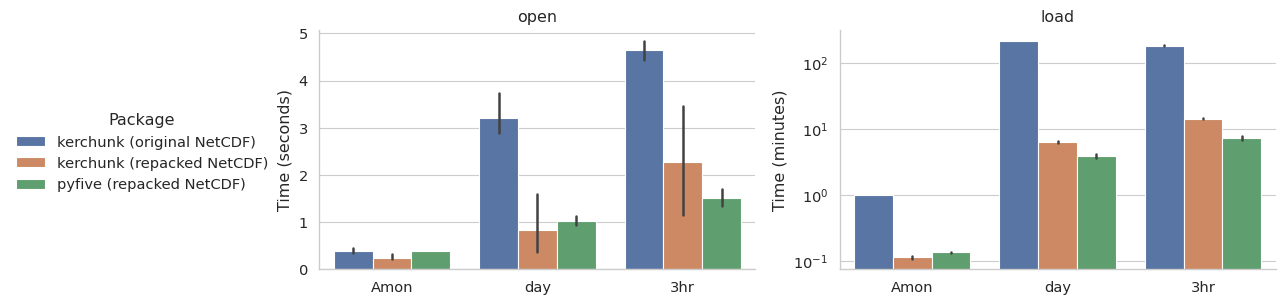

In [6]:
seaborn.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

palette = {
    "kerchunk (original NetCDF)": "#4C72B0",   # muted blue
    "kerchunk (repacked NetCDF)": "#DD8452",   # muted orange
    "pyfive (repacked NetCDF)": "#55A868"      # muted green
}

g = seaborn.catplot(
    data=df,
    kind="bar",
    x="frequency",
    y="time",
    col="name",
    hue="package",
    hue_order=[
        "kerchunk (original NetCDF)",
        "kerchunk (repacked NetCDF)",
        "pyfive (repacked NetCDF)"
    ],
    order=["Amon", "day", "3hr"],
    palette=palette,
    sharey=False,
    height=3.2,
    aspect=1.2,
    legend=True
)

g.set_axis_labels("", "Time (seconds)")
#g.set(yscale="log")
g.axes[0,1].set(yscale="log")
g.axes[0,1].set_ylabel("Time (minutes)")
g.set_titles(col_template="{col_name}")

# Remove top/right spines for a cleaner look
for ax in g.axes.flat:
    seaborn.despine(ax=ax)

seaborn.move_legend(
    g,
    "center left",
    bbox_to_anchor=(-0.25, 0.5),  # tweak this for spacing
    frameon=False,
    title="Package"
)

g.fig.tight_layout()
g.fig.savefig("test.pdf", bbox_inches="tight")

In [7]:
# g = seaborn.catplot(
#     df, kind="bar",
#     x="frequency", y="time", col="name",
#     hue="package",
#     hue_order=["kerchunk (original NetCDF)", "kerchunk (repacked NetCDF)", "pyfive"],
#     sharey=False)
# g.axes[0,0].set_ylabel("time (seconds)")
# g.axes[0,2].set(ylim=(0, 1000))
# g.fig.savefig("test.pdf")